# Exploratory Data Analysis

This notebook examines the dataset from https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations. The goals of this notebook are:
1. Understand the structure and content of the dataset.
2. Identify any missing or inconsistent data.
3. Generate summary statistics and visualizations to uncover patterns and insights.

## Getting started

Import necessary libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import sys
import chess
if ".." not in sys.path:
    sys.path.insert(0, '..')

from src.utils import fen_to_tensor

Loading the dataset

In [27]:
df = pd.read_csv("../dataset/raw/chessData.csv", nrows=100000) # not reading full 12M+ dataset
# df_random = pd.read_csv("../dataset/raw/random_evals.csv")
# df_tactics = pd.read_csv("../dataset/raw/tactic_evals.csv")

Basic info

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   FEN         100000 non-null  object
 1   Evaluation  100000 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [29]:
df.sample(5)

,FEN,Evaluation
18018,r1b1k2r/pp2pp1p/n1pp1npQ/q7/3PP3/2NB4/PPP1NPPP...,+63
78609,rn1qr1k1/1p4pp/2p2p1B/p1Pn3N/P1Q5/5P2/1P4PP/R4...,-7
9507,r2r2k1/5p1p/3pqnp1/P7/2p5/5Q1P/1P3PP1/R1BR2K1 ...,+63
17259,8/1p5k/pb1p1Bp1/2r3Q1/4PP2/7P/PP2R2K/2q5 w - -...,+1278
80097,3r3r/1bp1qpk1/pp2pnpp/4N3/1BPP4/3B4/PP2QPPP/3R...,+151


Turning `Evaluation` column to `int`

In [30]:
df = df[~df["Evaluation"].str.contains("#")]

In [31]:
df["Evaluation"] = df["Evaluation"].astype(int)
df.sample(5)

,FEN,Evaluation
8710,4Q2k/p5p1/1n6/3p4/1P6/q7/5PP1/3R2K1 b - - 1 51,1042
79440,1nq2rk1/3rbppp/pp1pp3/8/2P5/2NQ2P1/PP1BPPKP/R2...,-61
45298,rr6/4kp2/5p1p/3pb3/2q1b3/1RP1R3/PK4PP/2NQ4 w -...,-1166
79557,4r2k/1b2q1pp/p4r2/1pp1b3/4PpP1/1PP2B1P/PB3P2/2...,57
68479,4k3/3r1pp1/7p/3p1P1P/1R1Nn3/2P3K1/8/8 w - - 1 57,-151


In [32]:
df.describe()

,Evaluation
count,99446.000000
mean,37.356958
std,619.970342
min,-9024.000000
25%,-36.000000
50%,23.000000
75%,107.000000
max,7685.000000


Plotting the distribution of `Evaluation`

<Axes: ylabel='Frequency'>

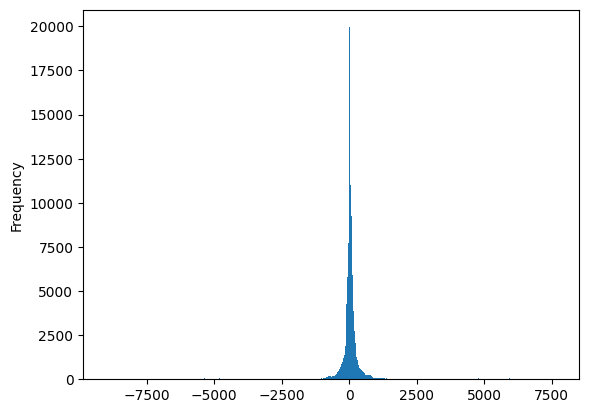

In [33]:
df['Evaluation'].plot.hist(bins=500)

Examining `FEN` column

In [34]:
df.sample(5)["FEN"].values

array(['r4rk1/pp3pbp/2nRb1p1/1N2q1B1/6P1/2N2Pn1/PPPQ4/2K2B1R w - - 1 22',
       'r2q1rk1/pp1bppbp/n2p1np1/3P4/7N/2N3PP/PP2PPB1/R1BQ1RK1 w - - 1 12',
       'r1bq1rk1/pp1nNppp/2pp1n2/4p3/3PPP2/4BN1P/P1PQB1P1/1R3RK1 b - - 0 13',
       'r4k1r/3qp1bp/1n1pp1pn/p1pP4/P4P2/2N2N2/1P2Q1PP/R1B2RK1 w - - 0 17',
       'r3k3/4bnp1/p1Rp3p/B2Pp3/pP3pP1/2NP3P/5P2/6K1 w - - 0 34'],
      dtype=object)

Converting `FEN` notation to suitable **tensor**

We’ll use this fixed order:

|Board #|Description|
|:-:|:-:|
|0|white pawn|
|1|white knight|
|2|white bishop|
|3|white rook|
|4|white queen|
|5|white king|
|6|black pawn|
|7|black knight|
|8|black bishop|
|9|black rook|
|10|black queen|
|11|black king|
|12|side to move (white=1, black=0)|
|13|white king-side castling|
|14|white queen-side castling|
|15|black king-side castling|
|16|black queen-side castling|
|17|en passant square|

In [106]:
samplee = df.sample().values[0]
samplee

array(['8/8/2p5/p1k1K3/P4Rp1/5bP1/8/8 w - - 21 81', 232], dtype=object)

In [107]:
planes = fen_to_tensor(samplee[0])
planes

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0., 

In [108]:
def plot_planes(planes: torch.Tensor = planes) -> None:
    plane_names = [
        "white pawn",
        "white knight",
        "white bishop",
        "white rook",
        "white queen",
        "white king",
        "black pawn",
        "black knight",
        "black bishop",
        "black rook",
        "black queen",
        "black king",
        "side to move (white=1, black=0)",
        "white king-side castling",
        "white queen-side castling",
        "black king-side castling",
        "black queen-side castling",
        "en passant square"
    ]
    planes = planes.cpu().numpy()

    fig, axes = plt.subplots(3, 6, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(18):
        ax = axes[i]
        ax.imshow(planes[i], cmap="gray", vmin=0, vmax=1)
        ax.set_title(plane_names[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

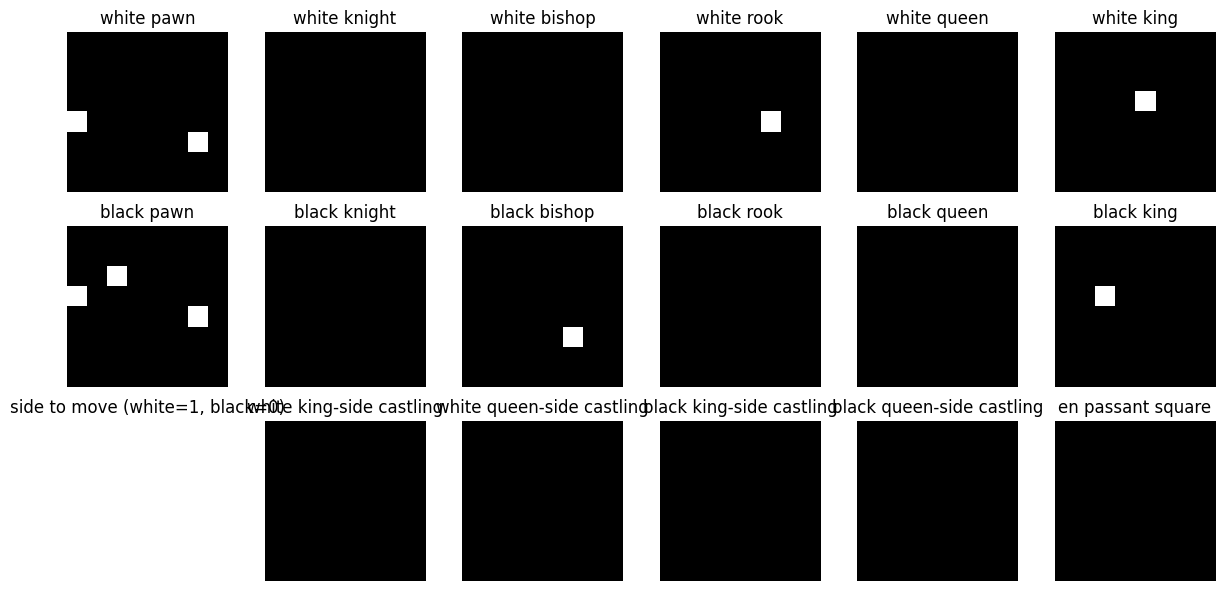

In [109]:
plot_planes(planes=planes)

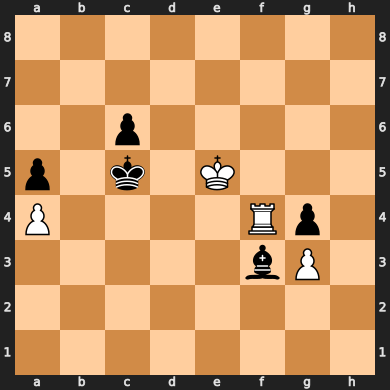

In [110]:
chess.Board(samplee[0])